In [50]:
# !pip install torch_geometric

In [51]:
import json
import logging
import random
import os
from pathlib import Path
from typing import Optional

import numpy as np
from tqdm import tqdm
import argparse
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split, DataLoader
from scipy.spatial import distance
import shutil
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine, euclidean

# Custom imports
import sys

sys.path.insert(1, "..")

from dependencies.data_generator import load_dataset
from dependencies.train_config import TrainConfig
from dependencies.GCN import (
    GAT_ver_1,
    GAT_ver_2,
    CustomDataset,
    TripletGraphDataset,
    train_model_accuracy,
    train_model_diversity,
    collate_triplets,
    collate_graphs,
)

In [52]:
with open("/home/udeneev-av/RAS/predicator-function-for-neural-networks/code/surrogate_hp_dev.json") as conf_file:
    config = json.load(conf_file)

In [53]:
model = GAT_ver_2(
    input_dim=config["input_dim"],
    output_dim=config["div_output_dim"],
    dropout=config["div_dropout"],
    heads=config["div_n_heads"],
    output_activation="none",
)

model.load_state_dict(torch.load("../surrogate_models/model_diversity.pth"))

<All keys matched successfully>

In [54]:
def load_dataset(config) -> None:
    dataset_path = Path("/home/udeneev-av/RAS/predicator-function-for-neural-networks/code/datasets/cifar100_archs")

    models_dict_path = []
    for file_path in tqdm(dataset_path.rglob("*.json"), desc="Loading dataset"):
        models_dict_path.append(file_path)

    return models_dict_path

In [55]:
dataset_paths = load_dataset(config)

Loading dataset: 1086it [00:00, 116321.00it/s]


In [56]:
dataset = CustomDataset(dataset_paths)

In [57]:
def _prepare_predictions(dataset_paths, num_samples: Optional[int] = None):
    preds = []
    for path in tqdm(dataset_paths, desc="Preparing predictions"):
        with path.open("r", encoding="utf-8") as f:
            data = json.load(f)
        prediction_name = (
            "valid_predictions" if "valid_predictions" in data else "test_predictions"
        )
        arr = np.array(data[prediction_name])
        preds.append(arr[:num_samples] if num_samples else arr)
    return preds


def get_diversity_matrix(dataset_paths, num_samples: Optional[int] = None) -> None:
    n = len(dataset_paths)
    M = np.eye(n)
    preds = _prepare_predictions(dataset_paths, num_samples)
    for i in tqdm(range(n), desc="Computing diversity matrix (i loop)"):
        for j in range(i + 1, n):
            dist = np.mean(preds[i] == preds[j])
            M[i, j] = M[j, i] = dist
    return M

def create_discrete_diversity_matrix(M) -> None:
    upper = np.quantile(M, 0.8, axis=1)
    lower = np.quantile(M, 0.2, axis=1)
    D = np.zeros_like(M)
    D[M > upper[:, None]] = 1
    D[M < lower[:, None]] = -1

    return D

M = get_diversity_matrix(dataset_paths)
D = create_discrete_diversity_matrix(M)

Computing diversity matrix (i loop): 100%|██████████| 1086/1086 [00:16<00:00, 66.08it/s] 


In [58]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.loader import DataLoader

# 1. Получаем все эмбеддинги
def get_all_embeddings(model, dataset, device=None):
    model.eval()
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    loader = DataLoader(dataset, batch_size=1, shuffle=False)
    embeddings = []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.batch)  # [1, D]
            embeddings.append(out.cpu().numpy().flatten())  # → [D]

    return np.array(embeddings)  # [N, D]

# Вычисляем все эмбеддинги
print("Computing embeddings for all models...")
embeddings = get_all_embeddings(model, dataset)  # [N, D]
print(f"Embeddings shape: {embeddings.shape}")


Computing embeddings for all models...
Embeddings shape: (1086, 16)


In [59]:
import torch
import numpy as np
from torch.utils.data import random_split

# Устанавливаем seed
torch.manual_seed(42)
np.random.seed(42)

# Параметры (пример, подставь свои)
config = {
    "n_models": len(dataset),
    "train_size": 0.8,  # как в обучении
    "models_dict_path": dataset_paths,
}

# Получаем accuracies (если нужно; если не используется — можно None)
# Здесь мы всё равно не используем accs, только структуру разбиения
accs = None  # или загрузи, если нужна инициализация

ds = CustomDataset(dataset_paths, accuracies=accs)

train_n = int(config["train_size"] * config["n_models"])
train_dataset, valid_dataset = random_split(ds, [train_n, config["n_models"] - train_n])

# Получаем индексы
train_indices = train_dataset.indices
valid_indices = valid_dataset.indices

# Преобразуем в set для быстрого поиска
train_indices_set = set(train_indices)
valid_indices_set = set(valid_indices)


In [60]:
n_samples = 100000
N = config["n_models"]

np.random.seed(42)
pairs = [tuple(np.random.choice(N, 2, replace=False)) for _ in range(n_samples)]

embedding_distances = []
prediction_agreements = []
pair_types = []  # "train", "valid", "mixed"

with torch.no_grad():
    for i, j in pairs:
        # Эмбеддинговое расстояние
        dist = euclidean(embeddings[i], embeddings[j])
        embedding_distances.append(dist)

        # Доля совпадающих ответов
        agreement = M[i, j]
        prediction_agreements.append(agreement)

        # Определяем тип пары
        i_in_train, j_in_train = i in train_indices_set, j in train_indices_set
        if i_in_train and j_in_train:
            pair_types.append("train")
        elif i not in train_indices_set and j not in train_indices_set:
            pair_types.append("valid")
        else:
            pair_types.append("mixed")

# Векторизуем
embedding_distances = np.array(embedding_distances)
prediction_agreements = np.array(prediction_agreements)
pair_types = np.array(pair_types)


Pair Type | Count  | Pearson Corr | Mean Agreement  | Mean Dist
----------------------------------------------------------------------
Train    | 63971  |       -0.718 |          0.494 | 2.951
Valid    | 3868   |       -0.790 |          0.491 | 2.962
Mixed    | 32161  |       -0.755 |          0.492 | 2.941


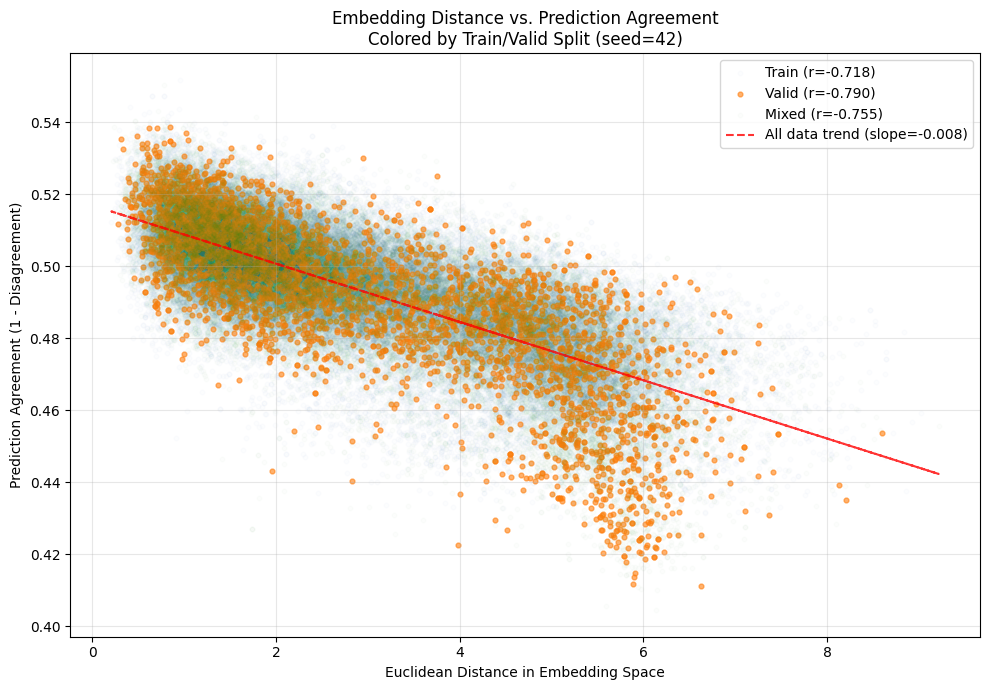


✅ Overall Pearson correlation (all pairs): -0.733


In [61]:
print(f"{'Pair Type':<8} | {'Count':<6} | {'Pearson Corr':<12} | {'Mean Agreement':<15} | {'Mean Dist'}")
print("-" * 70)

colors = {
    "train": "#1f77b4",   # синий
    "valid": "#ff7f0e",   # оранжевый
    "mixed": "#2ca02c",   # зелёный
}

plt.figure(figsize=(10, 7))

for ptype, color in colors.items():
    mask = pair_types == ptype
    x = embedding_distances[mask]
    y = prediction_agreements[mask]
    
    if len(x) < 2:
        corr = float('nan')
    else:
        corr = np.corrcoef(x, y)[0, 1]
    
    mean_agree = y.mean()
    mean_dist = x.mean()
    count = len(x)
    
    print(f"{ptype.capitalize():<8} | {count:<6} | {corr:12.3f} | {mean_agree:14.3f} | {mean_dist:.3f}")
    alpha = 0.6 if (ptype=="valid") else 0.01
    plt.scatter(x, y, c=color, label=f"{ptype.capitalize()} (r={corr:.3f})", alpha=alpha, s=12)

# Общая линия тренда (по всем данным)
z = np.polyfit(embedding_distances, prediction_agreements, 1)
p = np.poly1d(z)
plt.plot(embedding_distances, p(embedding_distances), "r--", alpha=0.8, label=f"All data trend (slope={z[0]:.3f})")

plt.xlabel("Euclidean Distance in Embedding Space")
plt.ylabel("Prediction Agreement (1 - Disagreement)")
plt.title("Embedding Distance vs. Prediction Agreement\nColored by Train/Valid Split (seed=42)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Итоговая корреляция по всем парам
total_corr = np.corrcoef(embedding_distances, prediction_agreements)[0, 1]
print(f"\n✅ Overall Pearson correlation (all pairs): {total_corr:.3f}")